# Chapter 2: Thermodynamic Foundations — EOS and Flash Calculations

This notebook covers the thermodynamic building blocks used in production optimization:

- **Equations of State (EOS)**: Comparing SRK and Peng-Robinson models
- **Flash calculations**: TP-flash for phase equilibrium
- **Thermophysical properties**: Density, heat capacity, enthalpy, viscosity, and Joule-Thomson coefficient

Understanding these fundamentals is essential for accurate modeling of fluid behavior
across the production system — from reservoir to export.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch02_thermodynamics_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# jneqsim is bound to the source JVM in the setup cell.

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

## 2.1 Helper: Create Fluid with a Given EOS

We define the same natural gas composition and create it with both SRK and PR
equations of state for comparison.

In [3]:
def create_fluid(eos_class, T_K, P_bara):
    """Create a natural gas fluid with the given EOS class."""
    fluid = eos_class(T_K, P_bara)
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("n-butane", 0.02)
    fluid.addComponent("CO2", 0.015)
    fluid.addComponent("nitrogen", 0.005)
    fluid.setMixingRule("classic")
    return fluid

# Verify both EOS work
for eos_name, eos_cls in [("SRK", SystemSrkEos), ("PR", SystemPrEos)]:
    f = create_fluid(eos_cls, 273.15 + 25.0, 100.0)
    ops = ThermodynamicOperations(f)
    ops.TPflash()
    f.initProperties()
    print(f"{eos_name}: density = {f.getDensity('kg/m3'):.2f} kg/m³, "
          f"Z = {f.getPhase('gas').getZ():.4f}")

SRK: density = 101.25 kg/m³, Z = 0.7804
PR: density = 102.90 kg/m³, Z = 0.7422


## 2.2 Figure 1 — Density Comparison: SRK vs PR

Both cubic EOS give similar trends, but PR typically predicts slightly higher
liquid densities. For gas at moderate pressures, the difference is small.

Maximum density difference (SRK - PR): 1.77 kg/m³


ch02_thermodynamics_figures.ipynb:cell6:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


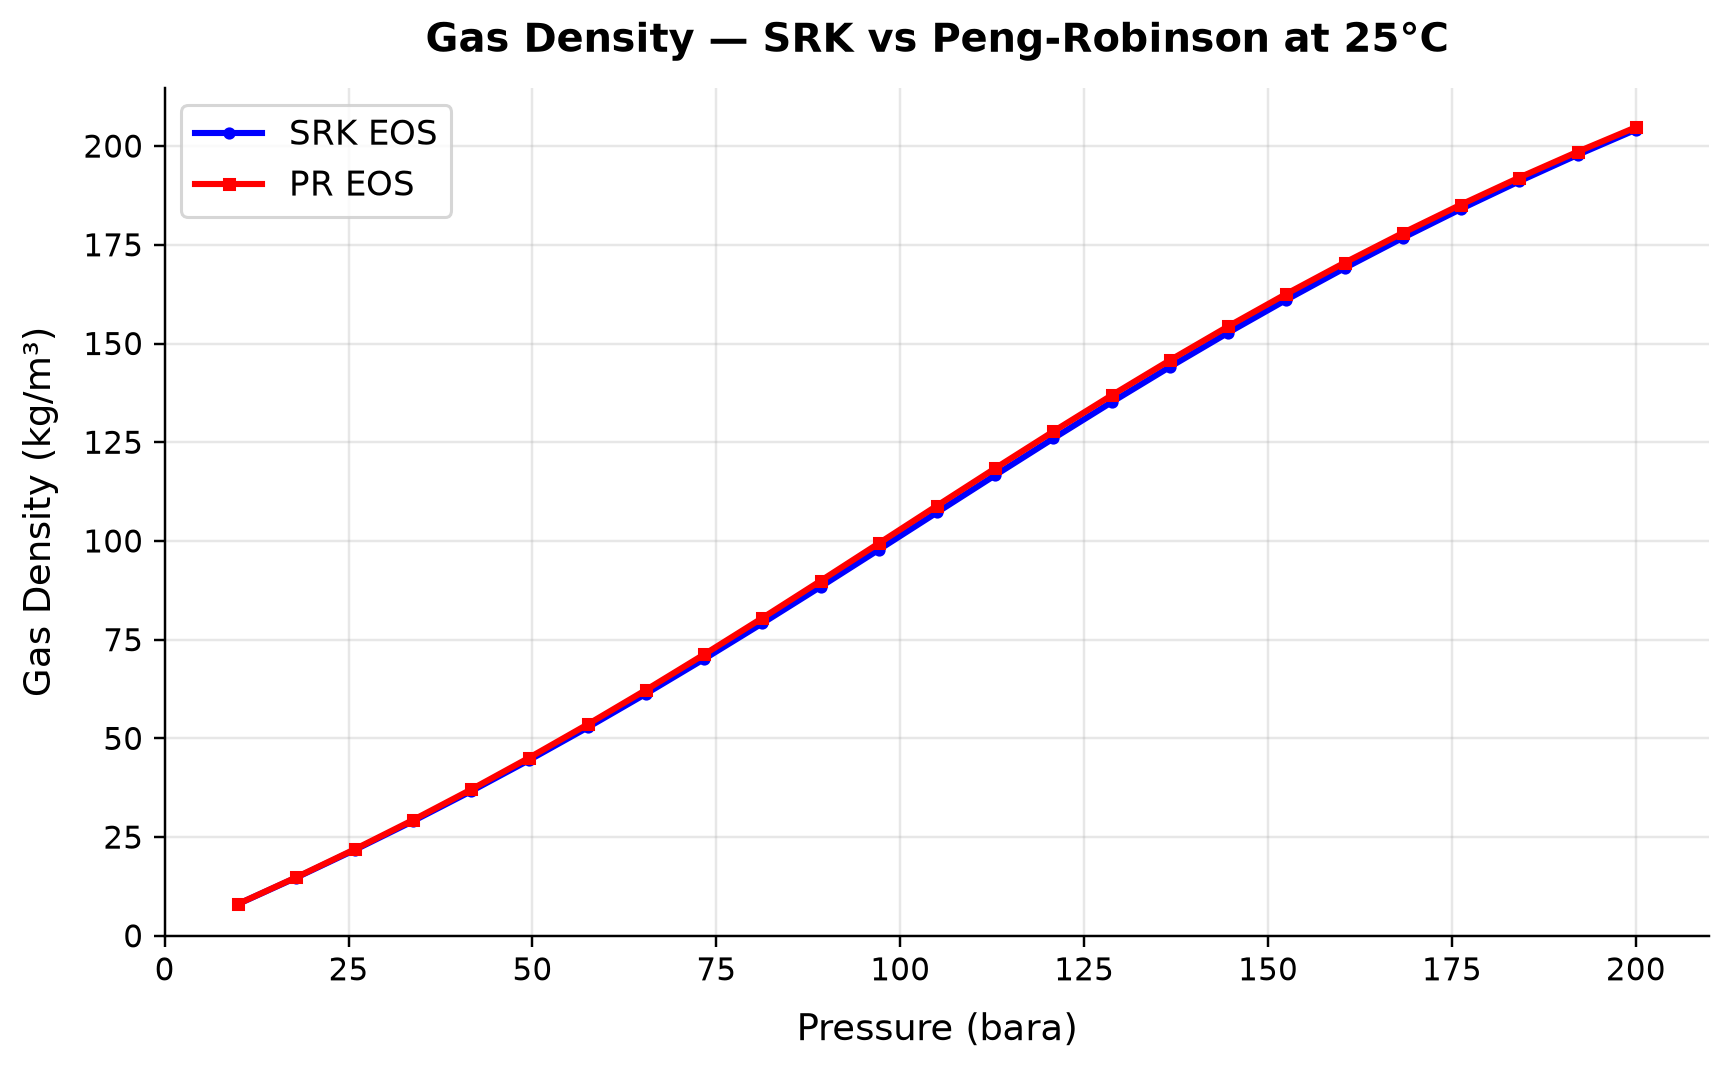

In [4]:
pressures = np.linspace(10, 200, 25)
T_K = 273.15 + 25.0

density_srk = []
density_pr = []

for P in pressures:
    for eos_cls, result_list in [(SystemSrkEos, density_srk), (SystemPrEos, density_pr)]:
        fluid = create_fluid(eos_cls, T_K, float(P))
        ops = ThermodynamicOperations(fluid)
        ops.TPflash()
        fluid.initProperties()
        result_list.append(fluid.getDensity("kg/m3"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures, density_srk, 'b-o', markersize=3, linewidth=2, label='SRK EOS')
ax.plot(pressures, density_pr, 'r-s', markersize=3, linewidth=2, label='PR EOS')
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Gas Density (kg/m³)', fontsize=12)
ax.set_title('Gas Density — SRK vs Peng-Robinson at 25°C', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 210)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig01_density_srk_vs_pr.png', dpi=220, bbox_inches='tight')
plt.show()

max_diff = max(abs(s - p) for s, p in zip(density_srk, density_pr))
print(f"Maximum density difference (SRK - PR): {max_diff:.2f} kg/m³")

**Executed-figure discussion.** SRK EOS: gas density spans 8.063–204.1 kg/m³ across the plotted cases. PR EOS: gas density spans 8.089–204.8 kg/m³ across the plotted cases.

SRK and Peng–Robinson use different cubic-EOS attraction and covolume expressions, so they predict different real-fluid volumes for the same composition. The difference is a model-form sensitivity; agreement between two models is not independent experimental validation. Compare the alternatives against measured PVT density over the intended envelope and carry the validated model into capacity calculations.


## 2.3 Figure 2 — Heat Capacity (Cp) vs Temperature

The isobaric heat capacity Cp increases as temperature rises, especially near
the phase boundary where latent heat effects become significant.

Cp range: 47.79 – 59.44 J/(mol·K)


ch02_thermodynamics_figures.ipynb:cell8:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


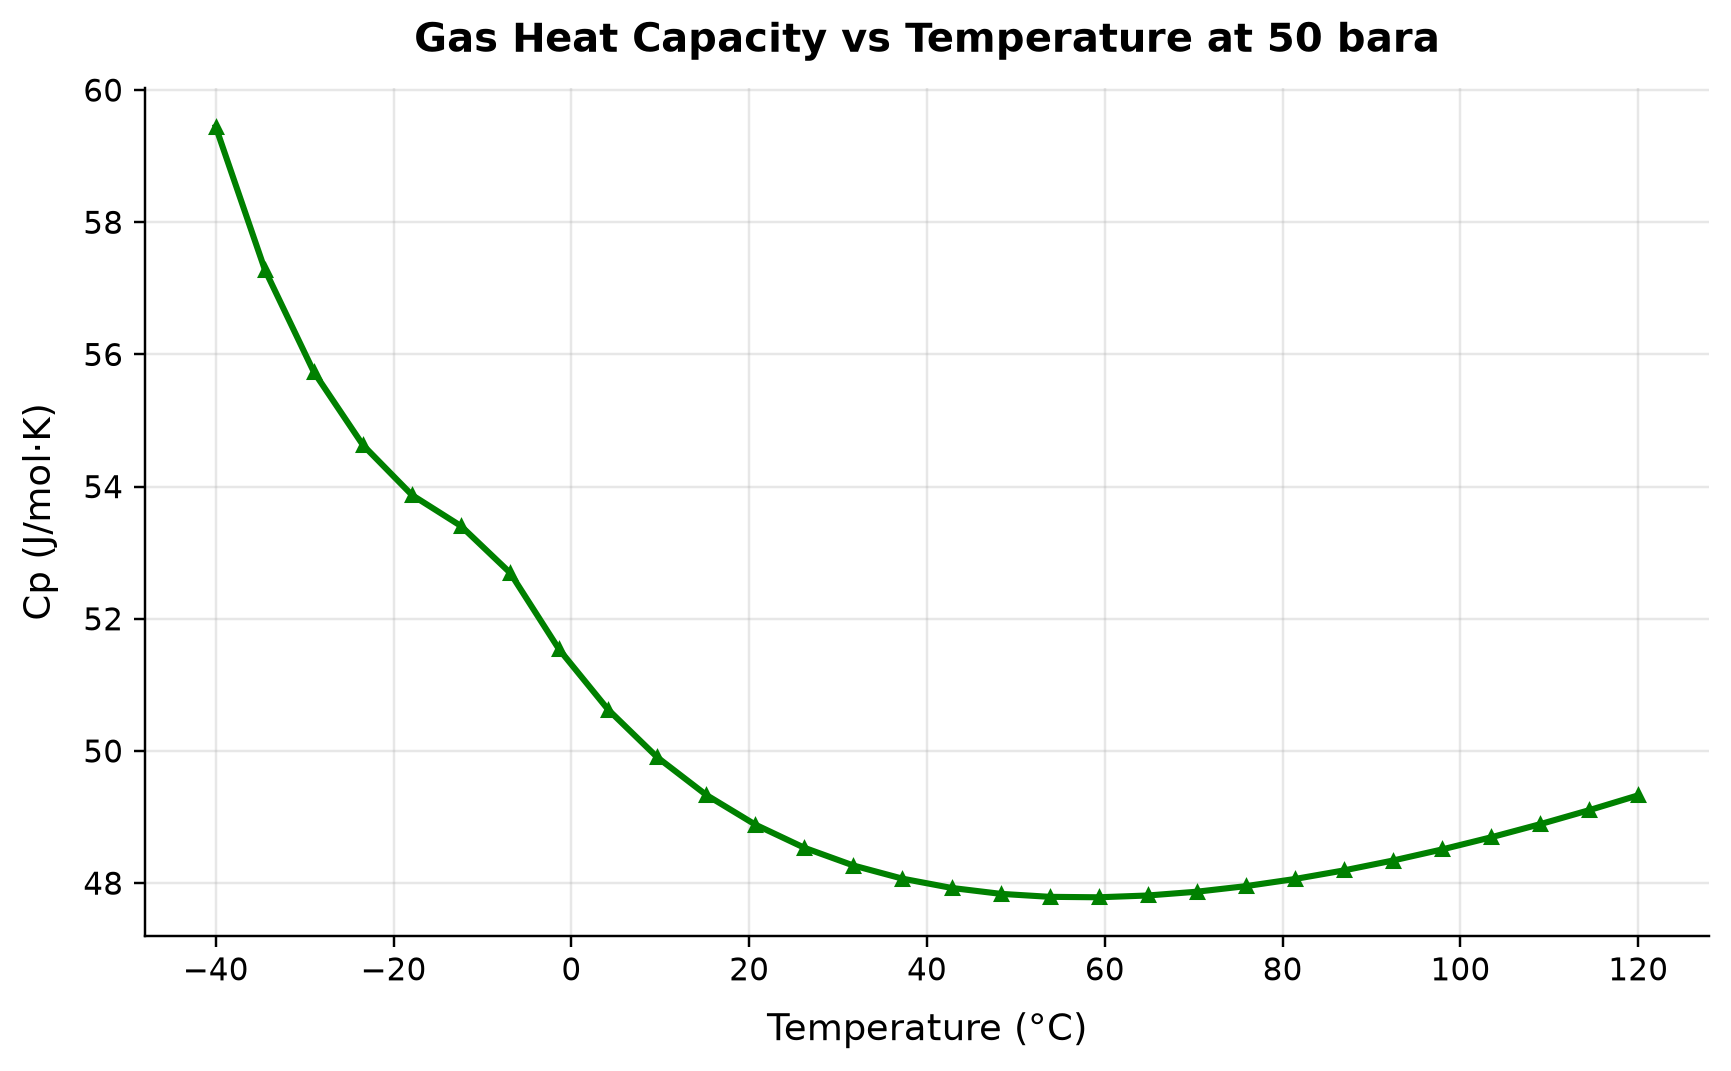

In [5]:
temperatures_C = np.linspace(-40, 120, 30)
P_bara = 50.0
cp_values = []

for T_C in temperatures_C:
    T_K = 273.15 + float(T_C)
    fluid = create_fluid(SystemSrkEos, T_K, P_bara)
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    # Get Cp of the gas phase in J/(mol·K)
    cp = fluid.getPhase("gas").getCp("J/molK")
    cp_values.append(cp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(temperatures_C, cp_values, 'g-^', markersize=4, linewidth=2)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Cp (J/mol·K)', fontsize=12)
ax.set_title('Gas Heat Capacity vs Temperature at 50 bara', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig02_cp_vs_temperature.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Cp range: {min(cp_values):.2f} – {max(cp_values):.2f} J/(mol·K)")

**Executed-figure discussion.** Cp spans 47.79–59.44 J/mol·K across the plotted cases.

Heat capacity measures the enthalpy response to temperature at fixed pressure and varies with molecular degrees of freedom and non-ideal interactions. A constant heat-capacity estimate may misstate heater duty or the temperature rise associated with compressor work. Use stream enthalpy differences for equipment energy balances and treat a constant Cp only as a local screening approximation.


## 2.4 Figure 3 — Enthalpy vs Temperature

Tracking enthalpy across a temperature range at constant pressure reveals the
energy content of the gas. This is crucial for heat exchanger and cooler design.

ch02_thermodynamics_figures.ipynb:cell10:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


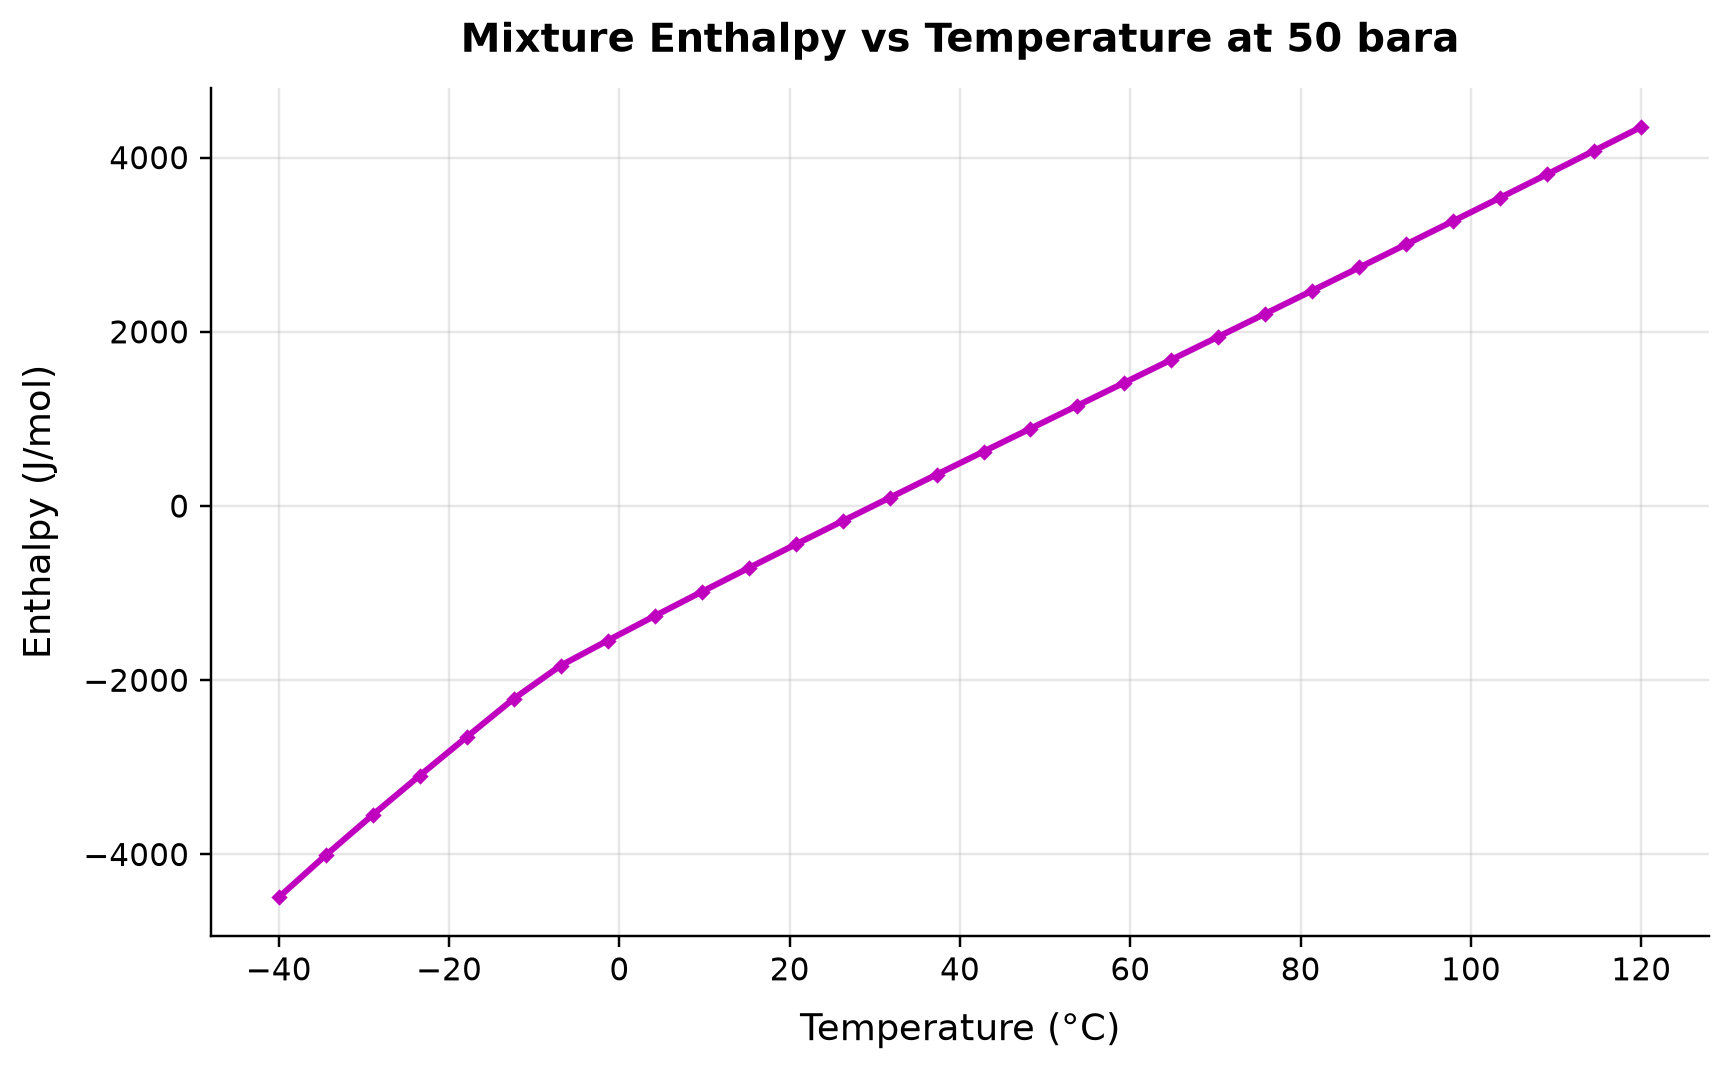

In [6]:
enthalpy_values = []

for T_C in temperatures_C:
    T_K = 273.15 + float(T_C)
    fluid = create_fluid(SystemSrkEos, T_K, P_bara)
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    h = fluid.getEnthalpy("J/mol")
    enthalpy_values.append(h)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(temperatures_C, enthalpy_values, 'm-D', markersize=3, linewidth=2)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Enthalpy (J/mol)', fontsize=12)
ax.set_title('Mixture Enthalpy vs Temperature at 50 bara', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig03_enthalpy_vs_temperature.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** Enthalpy spans -4492–4352 J/mol across the plotted cases.

The slope of an isobaric enthalpy curve is heat capacity; changes in phase distribution can add a latent-heat contribution. Duty is determined by the difference between inlet and outlet enthalpy, not the absolute value of an arbitrarily referenced enthalpy. Keep the same composition, flow basis and reference convention when calculating duty, and examine phase changes before fitting a straight line.


## 2.5 Figure 4 — Gas Viscosity vs Pressure

Gas viscosity increases with pressure as molecular interactions intensify.
Accurate viscosity prediction is essential for pipeline hydraulic calculations.

Viscosity range: 11.2 – 22.8 µPa·s


ch02_thermodynamics_figures.ipynb:cell12:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


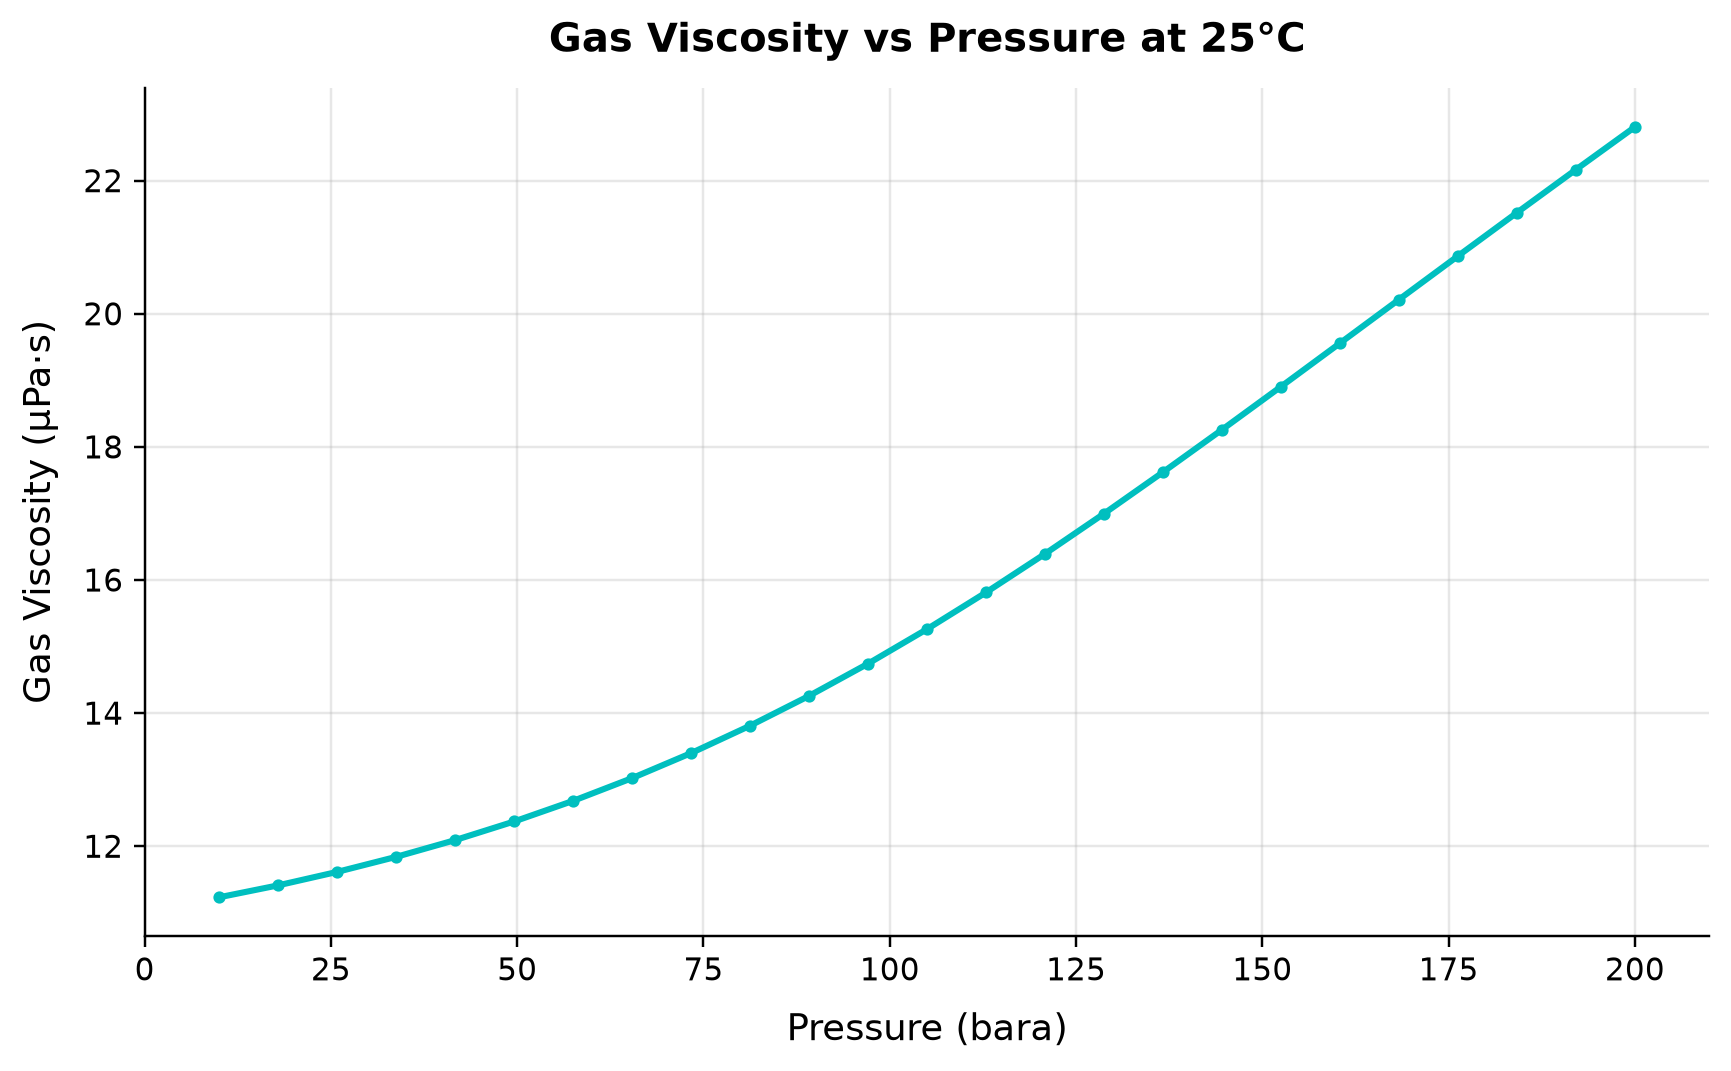

In [7]:
pressures_visc = np.linspace(10, 200, 25)
viscosities = []
T_K_visc = 273.15 + 25.0

for P in pressures_visc:
    fluid = create_fluid(SystemSrkEos, T_K_visc, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    mu = fluid.getPhase("gas").getViscosity("kg/msec")
    viscosities.append(mu * 1e6)  # convert to µPa·s (microPascal-seconds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures_visc, viscosities, 'c-o', markersize=3, linewidth=2)
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Gas Viscosity (µPa·s)', fontsize=12)
ax.set_title('Gas Viscosity vs Pressure at 25°C', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 210)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig04_viscosity_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Viscosity range: {min(viscosities):.1f} – {max(viscosities):.1f} µPa·s")

**Executed-figure discussion.** Gas Viscosity spans 11.23–22.81 µPa·s across the plotted cases.

Increasing gas density changes molecular momentum transport and therefore viscosity; the relationship is not the same as liquid-viscosity behavior. Viscosity affects Reynolds number, friction factor and ultimately the distribution of pressure losses. Initialize transport properties and recalculate them at local pipeline states when checking hydraulic capacity.


## 2.6 Figure 5 — Joule-Thomson Coefficient vs Pressure

The Joule-Thomson (JT) coefficient describes temperature change during
isenthalpic expansion (e.g., through a choke valve). A positive JT coefficient
means cooling on expansion — important for hydrate risk assessment.

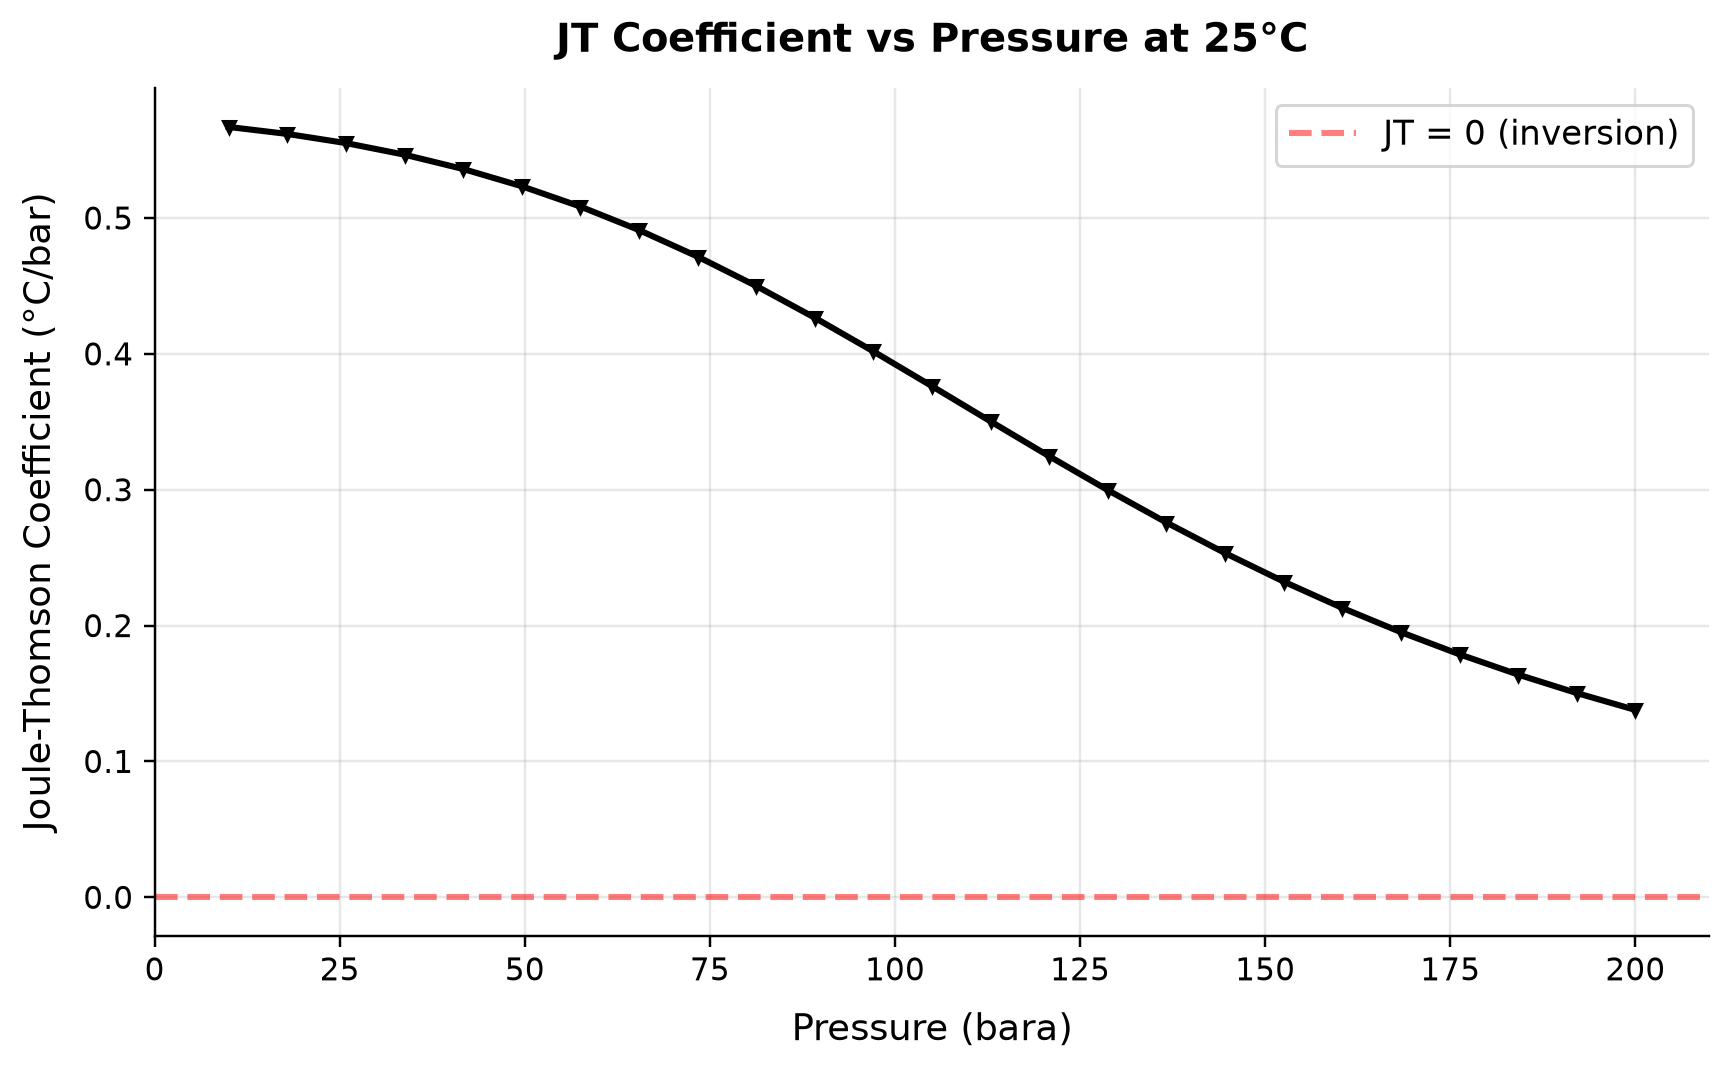

In [8]:
jt_coefficients = []

for P in pressures_visc:
    fluid = create_fluid(SystemSrkEos, T_K_visc, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    jt = fluid.getPhase("gas").getJouleThomsonCoefficient("C/bar")
    jt_coefficients.append(jt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures_visc, jt_coefficients, 'k-v', markersize=4, linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='JT = 0 (inversion)')
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Joule-Thomson Coefficient (°C/bar)', fontsize=12)
ax.set_title('JT Coefficient vs Pressure at 25°C', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 210)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig05_jt_coefficient_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** Joule-Thomson Coefficient spans 0.1379–0.567 °C/bar across the plotted cases.

The Joule–Thomson coefficient is the local temperature derivative with respect to pressure along a constant-enthalpy path. A positive coefficient predicts cooling for a pressure drop, but its changing magnitude prevents applying one inlet value over a large letdown. Use a PH flash for a finite valve pressure drop and inspect condensation and hydrate proximity along the resulting path.


## Summary

Key takeaways from this chapter:

1. **SRK vs PR**: Both EOS give similar gas-phase predictions; PR tends to predict slightly different densities
2. **Heat capacity**: Cp increases with temperature and is pressure-dependent — important for heater/cooler sizing
3. **Enthalpy**: Monotonically increases with temperature; the slope reflects Cp
4. **Viscosity**: Gas viscosity increases with pressure, affecting pipeline pressure drop calculations
5. **Joule-Thomson**: Positive JT coefficient means cooling on expansion — critical for choke valve design and hydrate prevention

Next chapter: **Fluid Characterization and PVT Modeling** for reservoir fluids with heavy fractions.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [9]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                              Figure  Panel             Series                      Output / unit  Minimum  Maximum  Finite points  Missing points
         fig01_density_srk_vs_pr.png      1            SRK EOS                Gas Density (kg/m³)  8.06343  204.141             25               0
         fig01_density_srk_vs_pr.png      1             PR EOS                Gas Density (kg/m³)  8.08894  204.759             25               0
         fig02_cp_vs_temperature.png      1            Curve 1                       Cp (J/mol·K)   47.786   59.442             30               0
   fig03_enthalpy_vs_temperature.png      1            Curve 1                   Enthalpy (J/mol) -4491.78  4352.02             30               0
     fig04_viscosity_vs_pressure.png      1            Curve 1              Gas Viscosity (µPa·s)  11.2328  22.8066             25               0
fig05_jt_coefficient_vs_pressure.png      1            Curve 1 Joule-Thomson Coefficient (°C/bar) 0.137913 0.566997   